In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import silhouette_score

# --- Load and combine data ---
# Replace this with the path to the local download if you download the 20k demonstration set from our repository
df = pd.read_csv('/Users/William/562Project/combined_models.csv')

In [93]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=75)
nn.fit(X_scaled)
distances, indices = nn.kneighbors(earth_scaled)
nearest_neighbors_df = df.iloc[indices[0]]
average_values = nearest_neighbors_df[['planet_radius_in_km', 
                                       'planet_surface_temperature_Kelvin', 
                                       'H2O', 'CO2', 'O2', 'N2', 'CH4']].mean()

print("\nAverage feature values of the 75 nearest neighbors to Earth:")
print(average_values)


Average feature values of the 75 nearest neighbors to Earth:
planet_radius_in_km                  6289.514332
planet_surface_temperature_Kelvin     277.806705
H2O                                     0.030130
CO2                                     0.065055
O2                                      0.182774
N2                                      0.674793
CH4                                     0.014080
dtype: float64


Everything below here is part of the exploratory analysis, before, during, and after the midterm report. It does not need to be considered for grading, but is left in as a demonstration as to why certain other methods were not chosen, which we did not have room to report on in the project report.

Text(0, 0.5, 'Inertia (WCSS)')

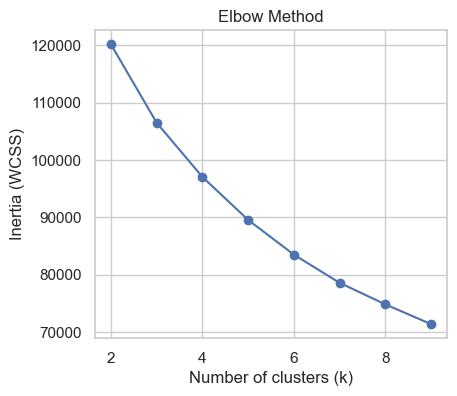

In [39]:
inertias = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)

# --- Plot Elbow Method ---
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (WCSS)')

For our usage, we are more interested in a subset "interesting" cluster rather than specifically sorting the planets into types, so we will choose k=5 as that is the closest to the 'elbow' without adding way too many clusters for the sake of lowering the inertia.

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

# --- Define your features and scale them ---
features = df[['planet_radius_in_km', 'planet_surface_temperature_Kelvin', 
               'H2O', 'CO2', 'O2', 'N2', 'CH4']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# --- Run K-Means clustering ---
kmeans = KMeans(n_clusters=5, random_state=1)
df['cluster'] = kmeans.fit_predict(X_scaled)

# --- Define Earth's data ---
earth_data = {
    'planet_radius_in_km': 6371,
    'planet_surface_temperature_Kelvin': 288.0,
    'H2O': 0.03,
    'CO2': 0.0004,
    'O2': 0.21,
    'N2': 0.78,
    'CH4': 0.00018
}
earth_df = pd.DataFrame([earth_data])
earth_scaled = scaler.transform(earth_df)
earth_cluster = kmeans.predict(earth_scaled)
print(f"Earth's predicted cluster: {earth_cluster}")

# --- Cluster Counts ---
cluster_counts = df['cluster'].value_counts().sort_index()
print("\nNumber of datapoints in each cluster:")
print(cluster_counts)

# --- Cluster Means ---
cluster_means = df.groupby('cluster')[['planet_radius_in_km','planet_surface_temperature_Kelvin', 
                                       'H2O', 'CO2', 'O2', 'N2', 'CH4']].mean()
print("\nAverage relevant feature values for each cluster:")
print(cluster_means)

/Users/William/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Earth's predicted cluster: [4]

Number of datapoints in each cluster:
cluster
0    4945
1    4983
2    3440
3    1185
4    5447
Name: count, dtype: int64

Average relevant feature values for each cluster:
         planet_radius_in_km  planet_surface_temperature_Kelvin       H2O  \
cluster                                                                     
0                7130.780533                         247.705521  0.032377   
1                6926.542492                         248.722669  0.032143   
2                6253.708753                         350.794233  0.026679   
3                6862.971029                         268.327807  0.086771   
4                7243.412307                         244.167045  0.030203   

              CO2        O2        N2       CH4  
cluster                                          
0        0.488933  0.203811  0.218553  0.031603  
1        0.228999  0.491445  0.187768  0.033259  
2        0.299142  0.306418  0.319433  0.026687  
3    

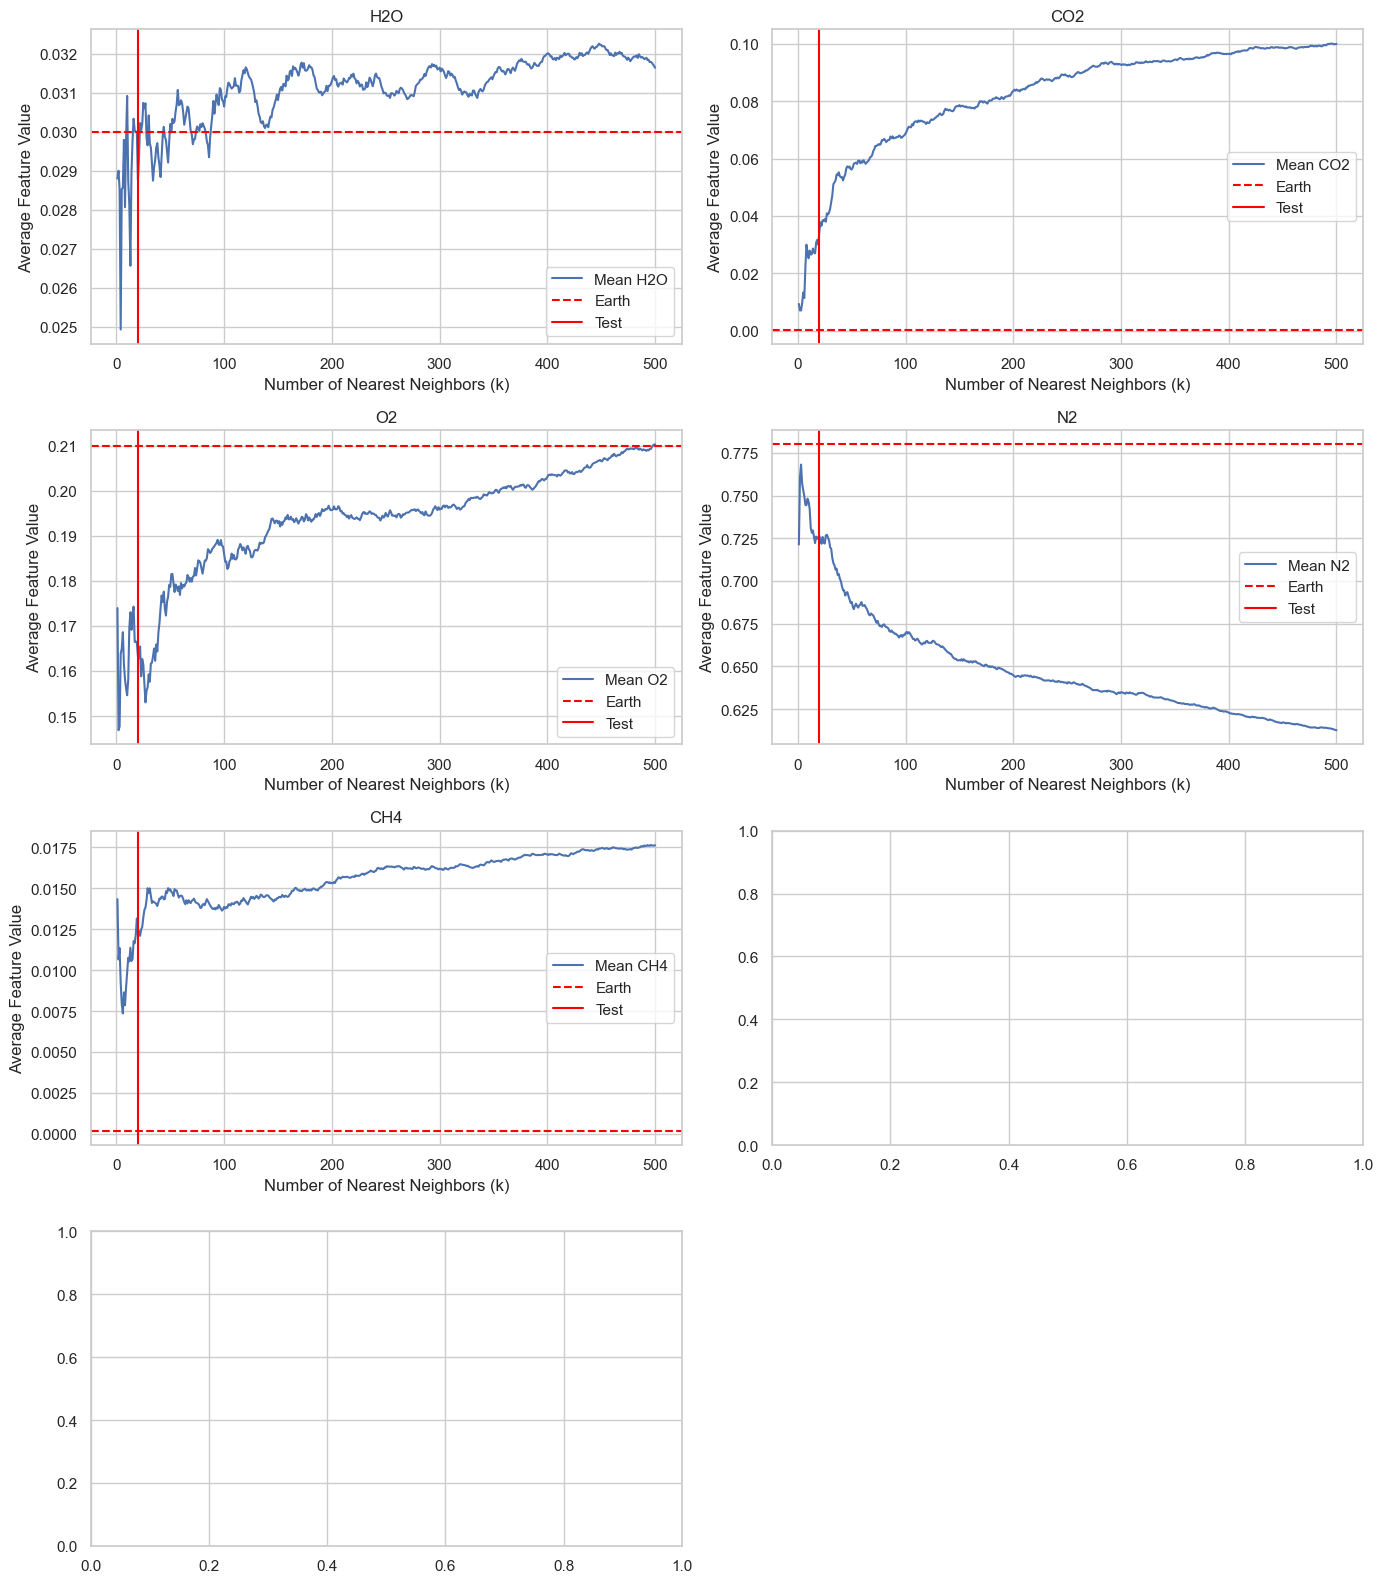

In [80]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import NearestNeighbors

# --- Fit NearestNeighbors on scaled exoplanet data ---
nn = NearestNeighbors(n_neighbors=1000)
nn.fit(X_scaled)

# --- Get the 1000 nearest neighbors to Earth ---
distances, indices = nn.kneighbors(earth_scaled, n_neighbors=1000)

# --- Extract Earth's feature values in order ---
earth_values = np.array([
    earth_data['H2O'],
    earth_data['CO2'],
    earth_data['O2'],
    earth_data['N2'],
    earth_data['CH4']
])

# --- Features list for labeling ---
feature_names = ['H2O', 'CO2', 'O2', 'N2', 'CH4']

# --- Prepare arrays to store the evolution of feature means ---
k_range = np.arange(1, 501)
mean_values = {feature: [] for feature in feature_names}

# --- Calculate rolling averages for each k ---
for k in k_range:
    neighbors_k = df.iloc[indices[0][:k]]
    for i, feature in enumerate(feature_names):
        mean_values[feature].append(neighbors_k[feature].mean())

# --- Plotting ---
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(14, 16))
axs = axs.ravel()

for i, feature in enumerate(feature_names):
    axs[i].plot(k_range, mean_values[feature], label=f'Mean {feature}')
    axs[i].axhline(y=earth_values[i], color='red', linestyle='--', label='Earth')
    axs[i].axvline(x=20, color='red', linestyle='-', label='Test')
    axs[i].set_title(feature)
    axs[i].set_xlabel('Number of Nearest Neighbors (k)')
    axs[i].set_ylabel('Average Feature Value')
    axs[i].legend()

# Hide the 8th subplot (empty)
axs[-1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def estimate_habitable_zone(stellar_temp, stellar_radius):
    # Normalize to solar values
    T_ratio = stellar_temp / 5778  # Sun's temperature
    R_ratio = stellar_radius       # Already in solar radii

    # Estimate stellar luminosity and derive HZ bounds
    L_ratio = R_ratio**2 * T_ratio**4
    hz_inner = 0.95 * (L_ratio ** 0.5)
    hz_outer = 1.37 * (L_ratio ** 0.5)
    return hz_inner, hz_outer

def score_planet(row):
    # Get star-specific HZ range
    hz_inner, hz_outer = estimate_habitable_zone(
        row['star_temperature_in_Kelvin'], 
        row['star_radius_in_Solar_radii']
    )
    
    # Initialize scores
    habitable_score = 0
    optimistic_score = 0
    
    # Habitability Conditions:
    if hz_inner <= row['semimajor_axis_of_the_planet_in_AU'] <= hz_outer:
        habitable_score += 1
    if 5000 <= row['planet_radius_in_km'] <= 12000:
        habitable_score += 1
    if 273 <= row['planet_surface_temperature_Kelvin'] <= 323:
        habitable_score += 1
    if 0.01 <= row['H2O'] <= 0.04:
        habitable_score += 1
    if 0.0001 <= row['CO2'] <= 0.001:
        habitable_score += 1
    if 0.19 <= row['O2'] <= 0.23:
        habitable_score += 1
    if 0.70 <= row['N2'] <= 0.80:
        habitable_score += 1
    if row['CH4'] < 0.0002:
        habitable_score += 1

    # Optimistic Conditions:
    if hz_inner <= row['semimajor_axis_of_the_planet_in_AU'] <= hz_outer:
        optimistic_score += 1
    if 5000 <= row['planet_radius_in_km'] <= 15000:
        optimistic_score += 1
    if 200 <= row['planet_surface_temperature_Kelvin'] <= 323:
        optimistic_score += 1
    if 0.005 <= row['H2O'] <= 0.04:
        optimistic_score += 1
    if 0.0001 <= row['CO2'] <= 0.01:
        optimistic_score += 1
    if 0.15 <= row['O2'] <= 0.23:
        optimistic_score += 1
    if 0.60 <= row['N2'] <= 0.80:
        optimistic_score += 1
    if row['CH4'] < 0.001:
        optimistic_score += 1

    return habitable_score, optimistic_score

# Example usage for applying this to a dataframe:
df[['habitable_score', 'optimistic_score']] = df.apply(score_planet, axis=1, result_type="expand")

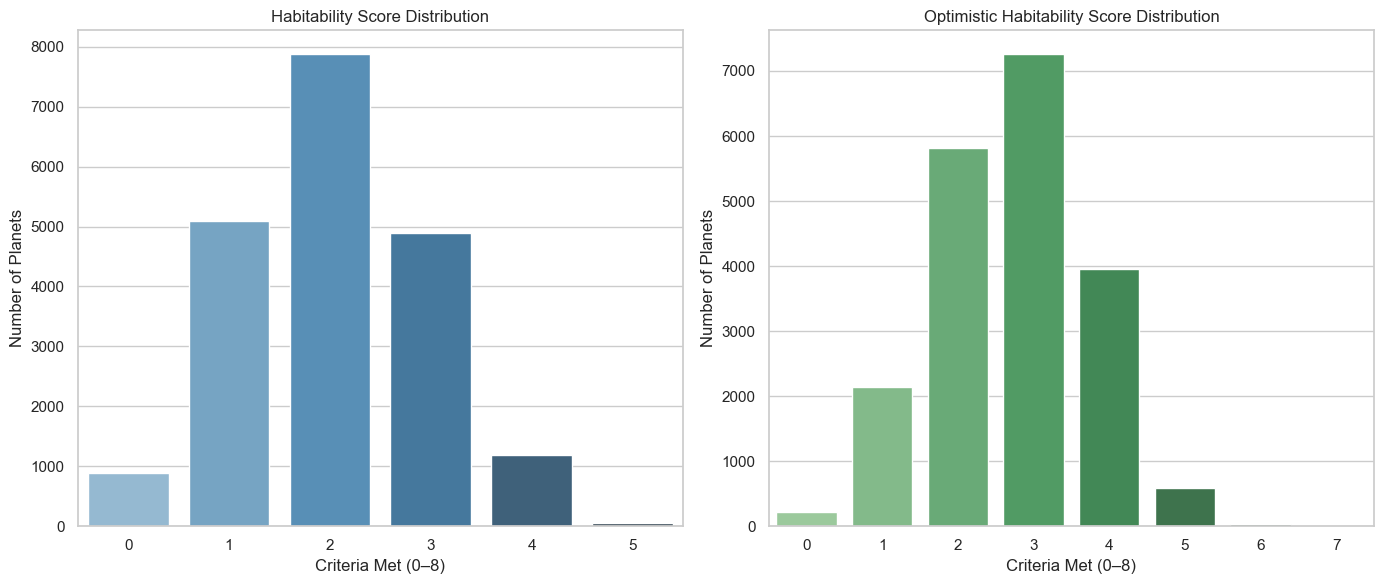

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plotting style
sns.set(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot habitability_score distribution
sns.countplot(data=df, x='habitable_score', palette='Blues_d', ax=axes[0])
axes[0].set_title('Habitability Score Distribution')
axes[0].set_xlabel('Criteria Met (0–8)')
axes[0].set_ylabel('Number of Planets')

# Plot optimistic_score distribution
sns.countplot(data=df, x='optimistic_score', palette='Greens_d', ax=axes[1])
axes[1].set_title('Optimistic Habitability Score Distribution')
axes[1].set_xlabel('Criteria Met (0–8)')
axes[1].set_ylabel('Number of Planets')

# Display the plots
plt.tight_layout()
plt.show()

In [6]:
def add_habitability_flags(row):
    hz_inner, hz_outer = estimate_habitable_zone(
        row['star_temperature_in_Kelvin'], 
        row['star_radius_in_Solar_radii']
    )
    
    row['criterion_orbit']  = int(hz_inner <= row['semimajor_axis_of_the_planet_in_AU'] <= hz_outer)
    row['criterion_radius'] = int(5000 <= row['planet_radius_in_km'] <= 15000)
    row['criterion_temp']   = int(200 <= row['planet_surface_temperature_Kelvin'] <= 323)
    row['criterion_H2O']    = int(0.005 <= row['H2O'] <= 0.04)
    row['criterion_CO2']    = int(0.0001 <= row['CO2'] <= 0.01)
    row['criterion_O2']     = int(0.15 <= row['O2'] <= 0.23)
    row['criterion_N2']     = int(0.60 <= row['N2'] <= 0.80)
    row['criterion_CH4']    = int(row['CH4'] < 0.001)
    
    return row

# Apply to all rows
df = df.apply(add_habitability_flags, axis=1)

In [7]:
criteria_cols = [
    'criterion_orbit', 'criterion_radius', 'criterion_temp',
    'criterion_H2O', 'criterion_CO2', 'criterion_O2',
    'criterion_N2', 'criterion_CH4'
]

# Sum each column to get count of planets passing each criterion
criteria_totals = df[criteria_cols].sum()
print(criteria_totals)

criterion_orbit      8159.0
criterion_radius    16077.0
criterion_temp      14679.0
criterion_H2O       11568.0
criterion_CO2         226.0
criterion_O2         2762.0
criterion_N2          709.0
criterion_CH4         325.0
dtype: float64
